   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 29.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 41.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 34.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 31.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


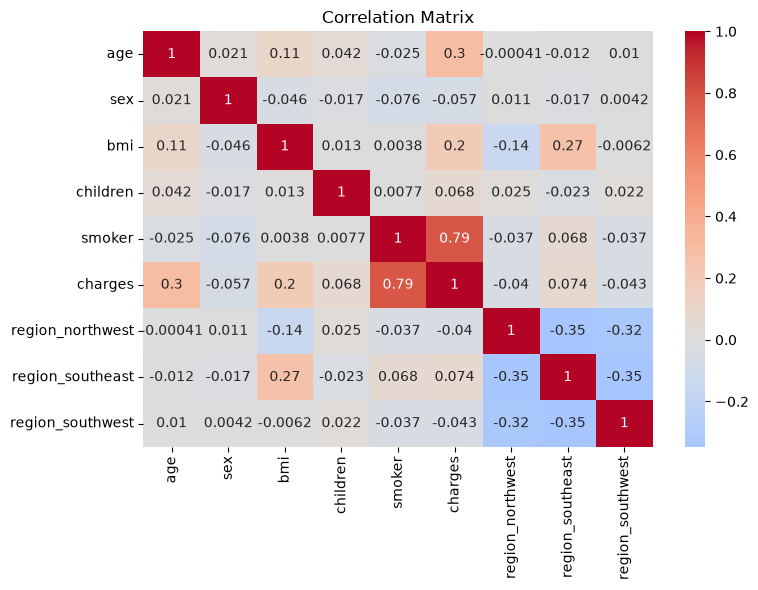

In [3]:
!pip install pandas
!pip install seaborn
!pip install matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")

# quick numeric encoding just for the correlation matrix
corr_df = df.copy()
corr_df['sex'] = corr_df['sex'].map({'male': 0, 'female': 1})
corr_df['smoker'] = corr_df['smoker'].map({'no': 0, 'yes': 1})
corr_df = pd.get_dummies(corr_df, columns=['region'], drop_first=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

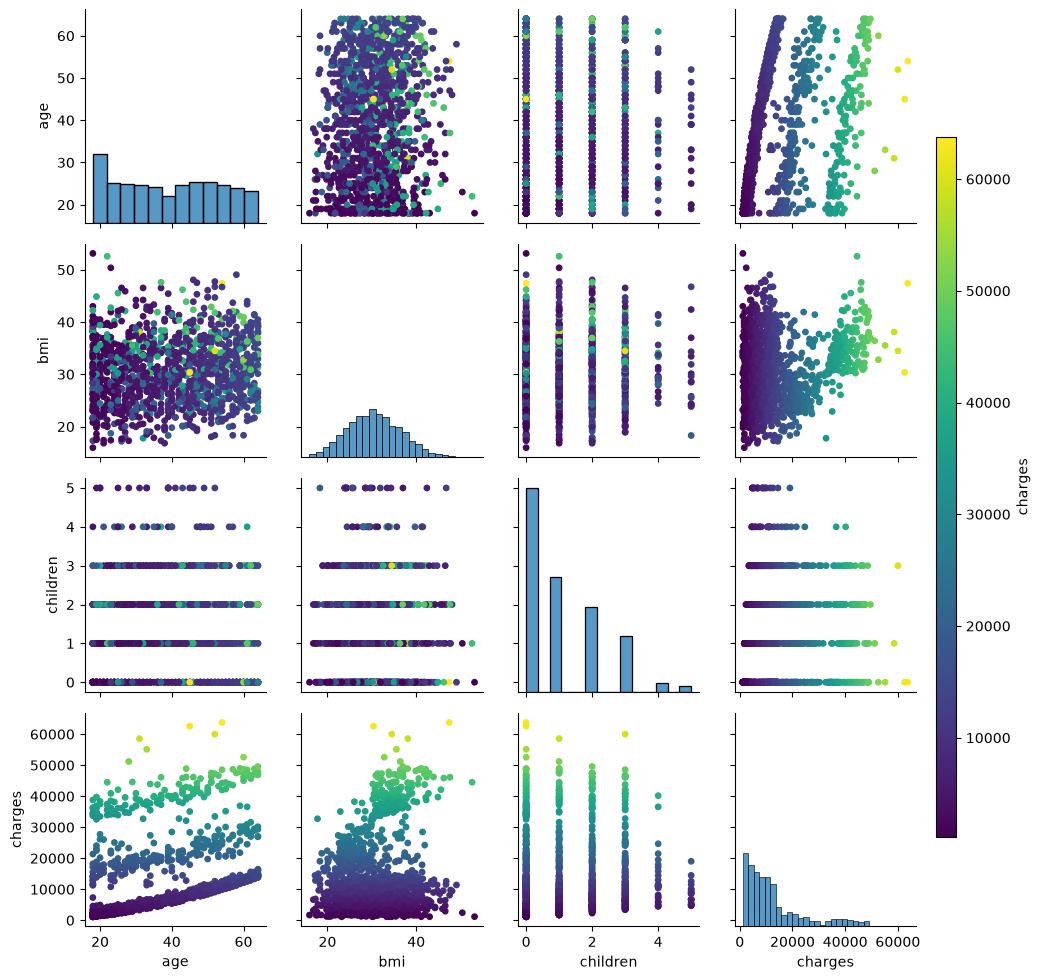

In [4]:
import numpy as np

vars_to_plot = ['age', 'bmi', 'children', 'charges']
g = sns.PairGrid(df, vars=vars_to_plot)
g.map_offdiag(lambda x, y, **kws: plt.scatter(x, y, c=df['charges'], cmap='viridis', s=15))
g.map_diag(sns.histplot)

# add a colorbar
plt.gcf().subplots_adjust(right=0.9)
cbar_ax = plt.gcf().add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(df['charges'].min(), df['charges'].max()))
plt.gcf().colorbar(sm, cax=cbar_ax, label='charges')

plt.show()

In [ ]:
!pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# select continuous predictors and add a constant (required for VIF to work correctly)
cont = df[['age', 'bmi', 'children']]
cont_sm = sm.add_constant(cont)

vif_data = pd.DataFrame()
vif_data['variable'] = cont_sm.columns
vif_data['VIF'] = [variance_inflation_factor(cont_sm.values, i) for i in range(cont_sm.shape[1])]

print(vif_data)

# essentially no multicollinearity between the numeric variables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 36.8 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 37.7 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [statsmodels] [statsmodels]
   variable       VIF
0     const  1.000000
1       age  1.013816
2       bmi  1.012152
3  children  1.001874


In [6]:

# ---------- 1. Baseline model: continuous + categorical ----------
X = pd.get_dummies(df.drop(columns='charges'), drop_first=True)  # remove charges (our target), turn text columns into 0/1 columns
X = X.astype(float)  # make sure every column is a number
X_sm = sm.add_constant(X)  # add a column of 1s so the model can calculate an intercept

baseline = sm.OLS(df['charges'], X_sm).fit()  # run the regression: predict charges using X_sm
print("BASELINE")  # label for the output
print(f"R²={baseline.rsquared:.4f}, Adj R²={baseline.rsquared_adj:.4f}\n")  # print how well the model fits (R² and adjusted R²)

# ---------- 2. Interaction: smoker x bmi ----------
X['smoker_bmi'] = X['smoker_yes'] * df['bmi']  # new column: bmi for smokers, 0 for non-smokers
X_sm2 = sm.add_constant(X)  # re-add the constant column now that X has a new column

model_smoker_bmi = sm.OLS(df['charges'], X_sm2).fit()  # re-run the regression with the new column included
print("BASELINE + smoker x bmi")  # label for the output
print(f"R²={model_smoker_bmi.rsquared:.4f}, Adj R²={model_smoker_bmi.rsquared_adj:.4f}\n")  # print the new fit scores

# ---------- 3. Interaction: smoker x age ----------
X['smoker_age'] = X['smoker_yes'] * df['age']  # new column: age for smokers, 0 for non-smokers
X_sm3 = sm.add_constant(X)  # re-add the constant column again

model_smoker_age = sm.OLS(df['charges'], X_sm3).fit()  # re-run the regression with both interactions included
print("BASELINE + smoker x bmi + smoker x age")  # label for the output
print(f"R²={model_smoker_age.rsquared:.4f}, Adj R²={model_smoker_age.rsquared_adj:.4f}\n")  # print the new fit scores

# ---------- 4. Polynomial: age^2 (centered first) ----------
X['age_sq'] = df['age']**2  # new column: centered age squared (lets the model curve)
X_sm4 = sm.add_constant(X)  # re-add the constant column again

model_full = sm.OLS(df['charges'], X_sm4).fit()  # re-run the regression with everything included
print("FULL MODEL (+ age^2)")  # label for the output
print(f"R²={model_full.rsquared:.4f}, Adj R²={model_full.rsquared_adj:.4f}\n")  # print the final fit scores

# ---------- 5. VIF on the full model ----------
vif_data = pd.DataFrame()  # create an empty table to hold the VIF results
vif_data['variable'] = X_sm4.columns  # first column of the table: names of each variable
vif_data['VIF'] = [variance_inflation_factor(X_sm4.values, i) for i in range(X_sm4.shape[1])]  # second column: VIF score for each variable (loops through them one by one)
print("VIF (full model):")  # label for the output
print(vif_data)  # show the VIF table

# ---------- 6. Compare all models side by side ----------
comparison = pd.DataFrame({  # build a summary table
    'Model': ['Baseline', '+smoker x bmi', '+smoker x age', '+age^2 (full)'],  # names of the 4 models
    'R2': [baseline.rsquared, model_smoker_bmi.rsquared,  # R² for each model, in the same order
           model_smoker_age.rsquared, model_full.rsquared],
    'Adj_R2': [baseline.rsquared_adj, model_smoker_bmi.rsquared_adj,  # adjusted R² for each model, same order
               model_smoker_age.rsquared_adj, model_full.rsquared_adj]
})
print("\nMODEL COMPARISON")  # label for the output
print(comparison)  # show the comparison table

BASELINE
R²=0.7509, Adj R²=0.7494

BASELINE + smoker x bmi
R²=0.8409, Adj R²=0.8398

BASELINE + smoker x bmi + smoker x age
R²=0.8409, Adj R²=0.8397

FULL MODEL (+ age^2)
R²=0.8435, Adj R²=0.8422

VIF (full model):
            variable        VIF
0              const   1.000000
1                age  47.833484
2                bmi   1.393919
3           children   1.102704
4           sex_male   1.011519
5         smoker_yes  31.085981
6   region_northwest   1.519872
7   region_southeast   1.654509
8   region_southwest   1.531387
9         smoker_bmi  25.672791
10        smoker_age   8.980041
11            age_sq  47.572756

MODEL COMPARISON
           Model        R2    Adj_R2
0       Baseline  0.750913  0.749414
1  +smoker x bmi  0.840918  0.839840
2  +smoker x age  0.840919  0.839720
3  +age^2 (full)  0.843465  0.842167
